In [1]:
import re
from pathlib import Path
import configparser
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_rows", 200)
pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 140)

In [6]:
PROJECT_ROOT = Path("..").resolve()
WORKLOAD = "tinymlp"

RUNS_DIR = PROJECT_ROOT / "results" / WORKLOAD

RESULTS_DIR = PROJECT_ROOT / "results"

assert RUNS_DIR.exists(), f"Can't find {RUNS_DIR}. Did runs finish and write results?"

print("Using runs dir:", RUNS_DIR)
print("Predictor subdirs:", [p.name for p in RUNS_DIR.iterdir() if p.is_dir()])

Using runs dir: /home/lp100067950/Downloads/Branch-Predictor-Project/results/tinymlp
Predictor subdirs: ['LAP', 'TAGE', 'BiModeBP', 'GshareBP']


In [3]:
STAT_LINE = re.compile(r"^([A-Za-z0-9_.:]+)\s+([-+0-9.eE]+)\s+#")

def load_stats(stats_path: Path) -> dict:
    stats = {}
    with stats_path.open() as f:
        for line in f:
            m = STAT_LINE.match(line.strip())
            if not m:
                continue
            k, v = m.group(1), m.group(2)
            try:
                stats[k] = float(v)
            except ValueError:
                pass
    return stats


def load_config_ini(config_path: Path) -> configparser.ConfigParser:
    cfg = configparser.ConfigParser(interpolation=None)
    # gem5's config.ini is compatible with ConfigParser
    cfg.read(config_path)
    return cfg


def _get_int(cfg: configparser.ConfigParser, section: str, key: str, default=None):
    try:
        return int(cfg[section][key])
    except Exception:
        return default


def _get_str(cfg: configparser.ConfigParser, section: str, key: str, default=None):
    try:
        return str(cfg[section][key])
    except Exception:
        return default


def _get_int_list(cfg: configparser.ConfigParser, section: str, key: str, default=None):
    """
    gem5 stores lists like: "13 9 9 9 9 9 9 9"
    """
    try:
        raw = cfg[section][key].strip()
        if raw == "":
            return default
        return [int(x) for x in raw.split()]
    except Exception:
        return default


def estimate_conditional_bp_storage_bits(cfg: configparser.ConfigParser):
    """
    Returns (bits_est, model_string).

    This estimates *conditional predictor* storage only.
    It intentionally excludes BTB/RAS/indirect predictors because those are
    typically constant across runs and not the point of BiMode vs TAGE tradeoffs.
    """
    sec_cond = "system.cpu.branchPred.conditionalBranchPred"
    sec_bp = "system.cpu.branchPred"
    sec_tage = "system.cpu.branchPred.conditionalBranchPred.tage"

    cond_type = _get_str(cfg, sec_cond, "type", default=None)

    # --- BiModeBP (in your runs: BranchPredictor wrapper + conditionalBranchPred=BiModeBP)
    if cond_type == "BiModeBP":
        choice_size = _get_int(cfg, sec_cond, "choicePredictorSize", 0)
        choice_bits = _get_int(cfg, sec_cond, "choiceCtrBits", 0)
        global_size = _get_int(cfg, sec_cond, "globalPredictorSize", 0)
        global_bits = _get_int(cfg, sec_cond, "globalCtrBits", 0)

        bits = choice_size * choice_bits + global_size * global_bits
        return bits, "BiModeBP:counters_only"

    # --- TAGE (in your runs: conditionalBranchPred.type=TAGE, with child .tage)
    if cond_type == "TAGE":
        log_sizes = _get_int_list(cfg, sec_tage, "logTagTableSizes", default=[])
        tag_widths = _get_int_list(cfg, sec_tage, "tagTableTagWidths", default=[])
        ctr_bits = _get_int(cfg, sec_tage, "tagTableCounterBits", 0)
        u_bits = _get_int(cfg, sec_tage, "tagTableUBits", 0)

        # Conservative + defensible approach:
        # Estimate only tagged tables (skip index 0 which is base/bimodal-related in many TAGE configs)
        bits = 0
        n = min(len(log_sizes), len(tag_widths))
        for i in range(1, n):
            entries = 2 ** log_sizes[i]
            bits_per_entry = tag_widths[i] + ctr_bits + u_bits
            bits += entries * bits_per_entry

        return bits, "TAGE:tagged_tables_only"

    # --- GshareBP case in your experiment:
    # Your config shows system.cpu.branchPred.type=GshareBP
    # plus conditionalBranchPred.type=LocalBP (required by your wrapper).
    bp_type = _get_str(cfg, sec_bp, "type", default=None)
    if bp_type == "GshareBP":
        gsize = _get_int(cfg, sec_bp, "global_predictor_size", 0)
        gbits = _get_int(cfg, sec_bp, "global_counter_bits", 0)

        # plus LocalBP attached as conditional predictor
        if cond_type == "LocalBP":
            lsize = _get_int(cfg, sec_cond, "localPredictorSize", 0)
            lbits = _get_int(cfg, sec_cond, "localCtrBits", 0)
        else:
            lsize = 0
            lbits = 0

        bits = gsize * gbits + lsize * lbits
        return bits, "GshareBP:PHT_plus_LocalBP"
        
    # --- LAPBP (bimodal base + LoopPredictor)
    if cond_type == "LAPBP":
        base_size = _get_int(cfg, sec_cond, "basePredictorSize", 0)
        base_bits = _get_int(cfg, sec_cond, "baseCtrBits", 0)
        base_storage = base_size * base_bits

        sec_lp = "system.cpu.branchPred.conditionalBranchPred.loop_predictor"
        log_sets = _get_int(cfg, sec_lp, "logSizeLoopPred", 0)
        log_assoc = _get_int(cfg, sec_lp, "logLoopTableAssoc", 0)

        sets = 2 ** log_sets
        ways = 2 ** log_assoc
        entries = sets * ways

        tag_bits = _get_int(cfg, sec_lp, "loopTableTagBits", 0)
        iter_bits = _get_int(cfg, sec_lp, "loopTableIterBits", 0)
        conf_bits = _get_int(cfg, sec_lp, "loopTableConfidenceBits", 0)
        age_bits = _get_int(cfg, sec_lp, "loopTableAgeBits", 0)

        # Approximate per-entry bits. Add a small constant for valid/dir/etc.
        per_entry = tag_bits + iter_bits + conf_bits + age_bits + 2
        loop_table_storage = entries * per_entry

        with_loop_bits = _get_int(cfg, sec_lp, "withLoopBits", 0)

        bits = base_storage + loop_table_storage + with_loop_bits
        return bits, "LAPBP:base_bimodal_plus_loop_table"

    # Fallback (unknown predictor)
    return None, f"unknown:{cond_type or bp_type}"


In [7]:
def discover_runs(results_dir: Path):
    """
    Expected:
      results/<workload>/<predictor>/stats.txt
    """
    runs = []
    for workload_dir in sorted(results_dir.iterdir()):
        if not workload_dir.is_dir():
            continue
        for pred_dir in sorted(workload_dir.iterdir()):
            if not pred_dir.is_dir():
                continue
            stats_path = pred_dir / "stats.txt"
            if stats_path.exists() and stats_path.stat().st_size > 0:
                runs.append((workload_dir.name, pred_dir.name, pred_dir, stats_path))
    return runs

runs = discover_runs(RESULTS_DIR)
print("Runs found:", len(runs))
runs[:5]

Runs found: 4


[('tinymlp',
  'BiModeBP',
  PosixPath('/home/lp100067950/Downloads/Branch-Predictor-Project/results/tinymlp/BiModeBP'),
  PosixPath('/home/lp100067950/Downloads/Branch-Predictor-Project/results/tinymlp/BiModeBP/stats.txt')),
 ('tinymlp',
  'GshareBP',
  PosixPath('/home/lp100067950/Downloads/Branch-Predictor-Project/results/tinymlp/GshareBP'),
  PosixPath('/home/lp100067950/Downloads/Branch-Predictor-Project/results/tinymlp/GshareBP/stats.txt')),
 ('tinymlp',
  'LAP',
  PosixPath('/home/lp100067950/Downloads/Branch-Predictor-Project/results/tinymlp/LAP'),
  PosixPath('/home/lp100067950/Downloads/Branch-Predictor-Project/results/tinymlp/LAP/stats.txt')),
 ('tinymlp',
  'TAGE',
  PosixPath('/home/lp100067950/Downloads/Branch-Predictor-Project/results/tinymlp/TAGE'),
  PosixPath('/home/lp100067950/Downloads/Branch-Predictor-Project/results/tinymlp/TAGE/stats.txt'))]

In [8]:
def pick_first(stats: dict, keys: list[str]):
    for k in keys:
        if k in stats:
            return k, stats[k]
    return None, None

def find_branch_counters(stats: dict):
    """
    Returns:
      (lookups_key, lookups_val, mispred_key, mispred_val)

    Different predictors expose different stat names. We try multiple common names
    and then fall back to keyword matching under branchPred.
        """
    lookup_candidates = [
        "system.cpu.branchPred.lookups_0::DirectCond",
        "system.cpu.branchPred.lookups_0::total",
        "system.cpu.branchPred.lookups",
        "system.cpu.branchPred.condLookups",
        "system.cpu.branchPred.condBranches",
        "system.cpu.branchPred.condPredicted",
    ]

    mispred_candidates = [
        "system.cpu.branchPred.mispredicted_0::DirectCond",
        "system.cpu.branchPred.mispredicted_0::total",
        "system.cpu.branchPred.incorrect",
        "system.cpu.branchPred.condIncorrect",
        "system.cpu.branchPred.condMispredicted",
        "system.cpu.branchPred.condWrong",
        "system.cpu.branchPred.mispredictions",
    ]

    lk_key, lk = pick_first(stats, lookup_candidates)
    mp_key, mp = pick_first(stats, mispred_candidates)

    # Fallback for lookups
    if lk is None:
        for k, v in stats.items():
            kl = k.lower()
            if "branchpred" in kl and ("lookup" in kl or "predicted" in kl):
                lk_key, lk = k, v
                break

    # Fallback for mispreds
    if mp is None:
        for k, v in stats.items():
            kl = k.lower()
            if "branchpred" in kl and ("misp" in kl or "incorrect" in kl or "wrong" in kl):
                mp_key, mp = k, v
                break

    return lk_key, lk, mp_key, mp

In [9]:
rows = []

predictor_dirs = sorted([p for p in RUNS_DIR.iterdir() if p.is_dir()])

for pdir in predictor_dirs:
    stats_path = pdir / "stats.txt"
    if not stats_path.exists() or stats_path.stat().st_size == 0:
        print("Skipping (missing/empty stats):", pdir)
        continue

    stats = load_stats(stats_path)

    ipc = stats.get("system.cpu.ipc", None)
    cpi = stats.get("system.cpu.cpi", None)
    simInsts = stats.get("simInsts", None)
    simTicks = stats.get("simTicks", None)
    hostSeconds = stats.get("hostSeconds", None)

    lk_key, lk, mp_key, mp = find_branch_counters(stats)

    mispred_rate = None
    if lk is not None and mp is not None and lk > 0:
        mispred_rate = mp / lk

    # --- NEW: predictor storage estimate from config.ini
    config_path = pdir / "config.ini"
    storage_bits = None
    storage_model = None
    storage_bytes = None
    storage_kb = None
    if config_path.exists() and config_path.stat().st_size > 0:
        cfg = load_config_ini(config_path)
        storage_bits, storage_model = estimate_conditional_bp_storage_bits(cfg)
        if storage_bits is not None:
            storage_bytes = storage_bits / 8.0
            storage_kb = storage_bytes / 1024.0

    rows.append({
        "predictor": pdir.name,
        "ipc": ipc,
        "cpi": cpi,
        "simInsts": simInsts,
        "simTicks": simTicks,
        "hostSeconds": hostSeconds,
        "bp_lookups": lk,
        "bp_mispreds": mp,
        "mispred_rate": mispred_rate,
        "bp_lookup_stat": lk_key,
        "bp_mispred_stat": mp_key,
        "stats_path": str(stats_path.relative_to(PROJECT_ROOT)),

        # NEW columns
        "bp_storage_bits_est": storage_bits,
        "bp_storage_kb_est": storage_kb,
        "bp_storage_model": storage_model,
        "config_path": str(config_path.relative_to(PROJECT_ROOT)) if config_path.exists() else None,
    })

df = pd.DataFrame(rows).sort_values("predictor").reset_index(drop=True)
df

,predictor,ipc,cpi,simInsts,simTicks,hostSeconds,bp_lookups,bp_mispreds,mispred_rate,bp_lookup_stat,bp_mispred_stat,stats_path,bp_storage_bits_est,bp_storage_kb_est,bp_storage_model,config_path
0,BiModeBP,1.919220,0.521045,10000000.0,2.605224e+09,16.40,6179435.0,238361.0,0.038573,system.cpu.branchPred.lookups_0::total,system.cpu.branchPred.mispredicted_0::total,results/tinymlp/BiModeBP/stats.txt,32768,4.000000,BiModeBP:counters_only,results/tinymlp/BiModeBP/config.ini
1,GshareBP,1.007359,0.992695,10000001.0,4.963473e+09,33.70,15563541.0,684250.0,0.043965,system.cpu.branchPred.lookups_0::total,system.cpu.branchPred.mispredicted_0::total,results/tinymlp/GshareBP/stats.txt,5120,0.625000,GshareBP:PHT_plus_LocalBP,results/tinymlp/GshareBP/config.ini
2,LAP,0.568761,1.758206,10000001.0,8.791031e+09,47.09,11442848.0,1391801.0,0.121631,system.cpu.branchPred.lookups_0::total,system.cpu.branchPred.mispredicted_0::total,results/tinymlp/LAP/stats.txt,45063,5.500854,LAPBP:base_bimodal_plus_loop_table,results/tinymlp/LAP/config.ini
3,TAGE,3.661019,0.273148,10000003.0,1.365740e+09,11.93,2722479.0,4871.0,0.001789,system.cpu.branchPred.lookups_0::total,system.cpu.branchPred.mispredicted_0::total,results/tinymlp/TAGE/stats.txt,54784,6.687500,TAGE:tagged_tables_only,results/tinymlp/TAGE/config.ini


In [10]:
df[["predictor","mispred_rate","bp_lookup_stat","bp_mispred_stat"]]

,predictor,mispred_rate,bp_lookup_stat,bp_mispred_stat
0,BiModeBP,0.038573,system.cpu.branchPred.lookups_0::total,system.cpu.branchPred.mispredicted_0::total
1,GshareBP,0.043965,system.cpu.branchPred.lookups_0::total,system.cpu.branchPred.mispredicted_0::total
2,LAP,0.121631,system.cpu.branchPred.lookups_0::total,system.cpu.branchPred.mispredicted_0::total
3,TAGE,0.001789,system.cpu.branchPred.lookups_0::total,system.cpu.branchPred.mispredicted_0::total


In [11]:
BASELINE = "BiModeBP"
base_ipc = df.loc[df["predictor"] == BASELINE, "ipc"].iloc[0]

df2 = df.copy()
df2["speedup_vs_bimode"] = df2["ipc"] / base_ipc
df2.sort_values("speedup_vs_bimode", ascending=False)[["predictor","ipc","speedup_vs_bimode","mispred_rate","cpi"]]

,predictor,ipc,speedup_vs_bimode,mispred_rate,cpi
3,TAGE,3.661019,1.907556,0.001789,0.273148
0,BiModeBP,1.919220,1.000000,0.038573,0.521045
1,GshareBP,1.007359,0.524879,0.043965,0.992695
2,LAP,0.568761,0.296350,0.121631,1.758206


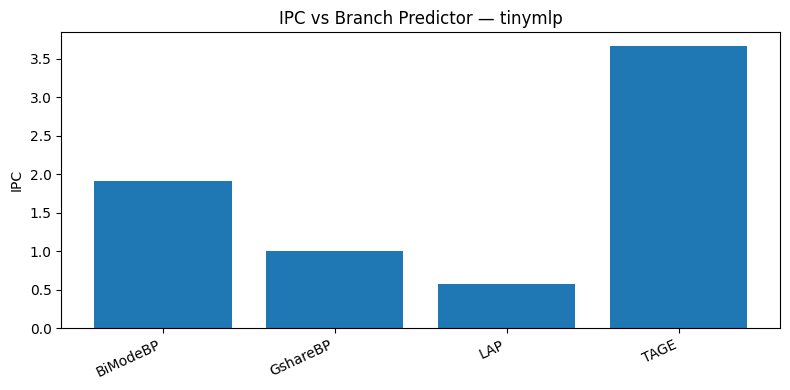

In [12]:
plt.figure(figsize=(8,4))
plt.bar(df["predictor"], df["ipc"])
plt.title(f"IPC vs Branch Predictor — {WORKLOAD}")
plt.ylabel("IPC")
plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.show()

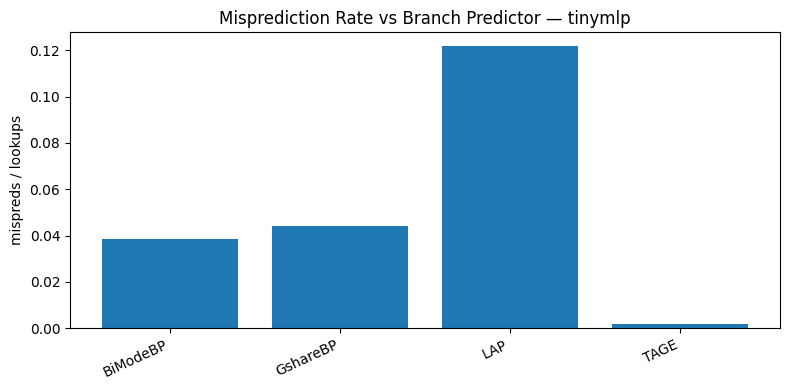

In [13]:
plt.figure(figsize=(8,4))
plt.bar(df["predictor"], df["mispred_rate"])
plt.title(f"Misprediction Rate vs Branch Predictor — {WORKLOAD}")
plt.ylabel("mispreds / lookups")
plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.show()

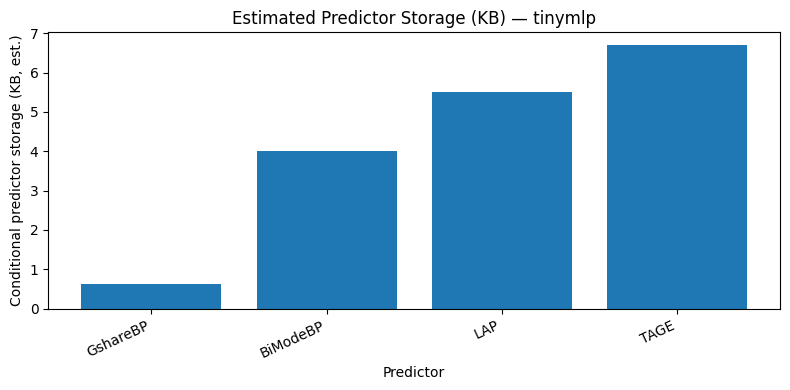

In [14]:
df_plot = df.dropna(subset=["bp_storage_kb_est"]).sort_values("bp_storage_kb_est").reset_index(drop=True)

plt.figure(figsize=(8, 4))
plt.bar(df_plot["predictor"], df_plot["bp_storage_kb_est"])
plt.title(f"Estimated Predictor Storage (KB) — {WORKLOAD}")
plt.xlabel("Predictor")
plt.ylabel("Conditional predictor storage (KB, est.)")
plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.show()

In [15]:
out_csv = PROJECT_ROOT / "results" / f"{WORKLOAD}_predictor_comparison.csv"
df.to_csv(out_csv, index=False)
print("Wrote:", out_csv)

Wrote: /home/lp100067950/Downloads/Branch-Predictor-Project/results/tinymlp_predictor_comparison.csv


In [16]:
df[["predictor","bp_lookup_stat","bp_mispred_stat","bp_lookups","bp_mispreds","mispred_rate","ipc"]]

,predictor,bp_lookup_stat,bp_mispred_stat,bp_lookups,bp_mispreds,mispred_rate,ipc
0,BiModeBP,system.cpu.branchPred.lookups_0::total,system.cpu.branchPred.mispredicted_0::total,6179435.0,238361.0,0.038573,1.919220
1,GshareBP,system.cpu.branchPred.lookups_0::total,system.cpu.branchPred.mispredicted_0::total,15563541.0,684250.0,0.043965,1.007359
2,LAP,system.cpu.branchPred.lookups_0::total,system.cpu.branchPred.mispredicted_0::total,11442848.0,1391801.0,0.121631,0.568761
3,TAGE,system.cpu.branchPred.lookups_0::total,system.cpu.branchPred.mispredicted_0::total,2722479.0,4871.0,0.001789,3.661019
